# Salary Insights by Job Role

In [77]:
import pandas as pd
df=pd.read_csv('Dataset/salaries.csv')
df1=df.copy()

In [78]:
import os
folder = "models"
if not os.path.exists(folder):
    os.makedirs(folder)

## Data Preprocessing


In [79]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(42)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [82]:
df['employment_type'].value_counts()

employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64

In [83]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

def preprocess_salary_df(df):
    df = df.copy()

    # Separate target
    X = df.drop("salary_in_usd", axis=1)
    y = df["salary_in_usd"]  # ORIGINAL USD VALUES

    # Identify columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    obj_cols = X.select_dtypes(include=['object']).columns

    # Scale ONLY feature numeric columns
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    # Encode categorical columns
    encoders = {}
    for col in obj_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        encoders[col] = le

    return X, y, scaler, encoders


In [84]:
X, y, scaler, encoders = preprocess_salary_df(df)


## Exploratory Data Analysis

C:\Users\bhuky\AppData\Local\Temp\ipykernel_1660\1634509449.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["salary_in_usd"], kde=True)


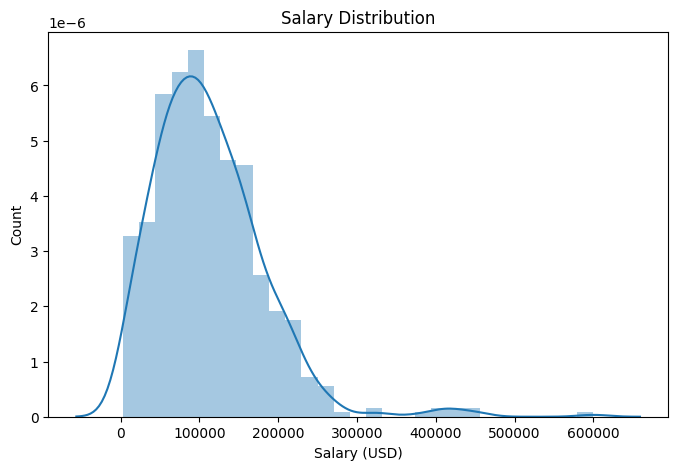

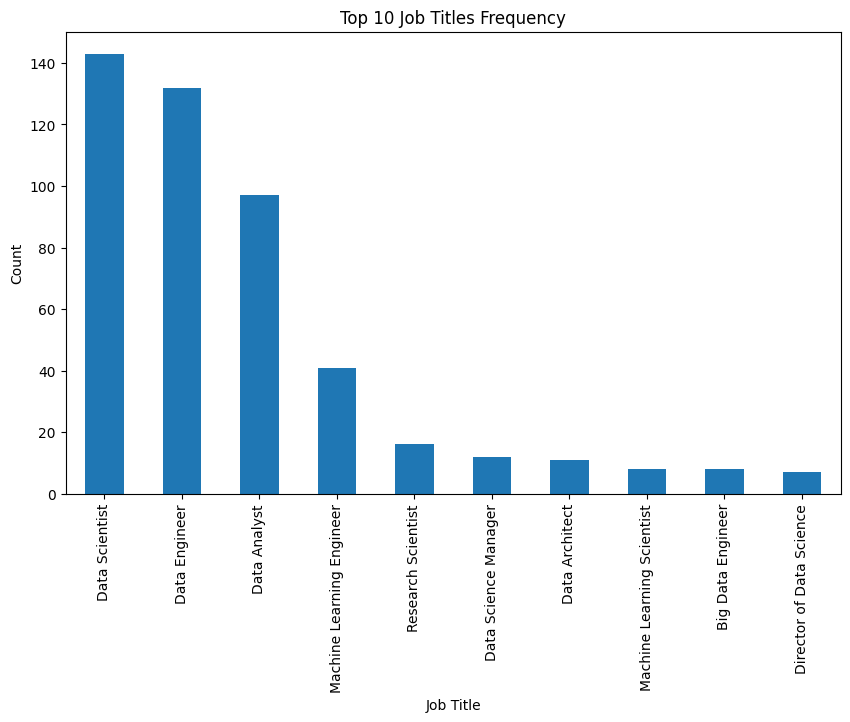

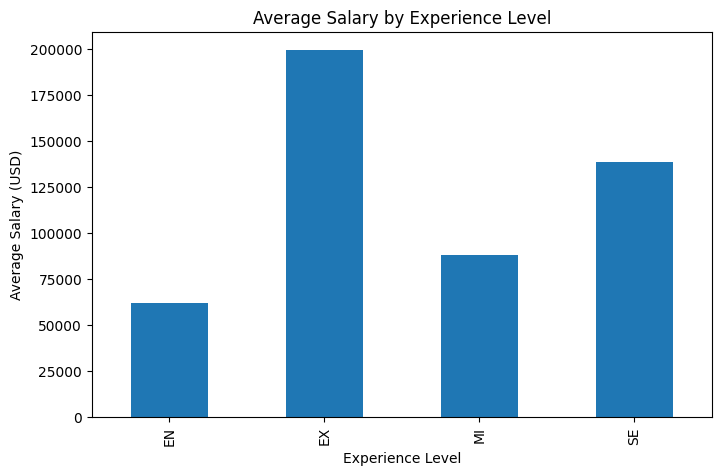

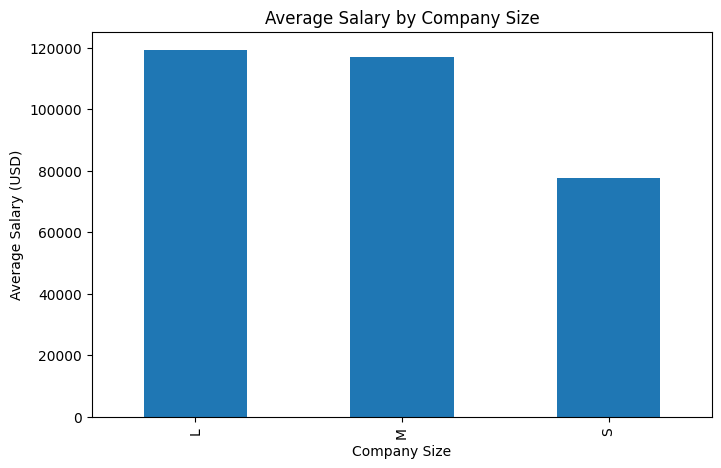

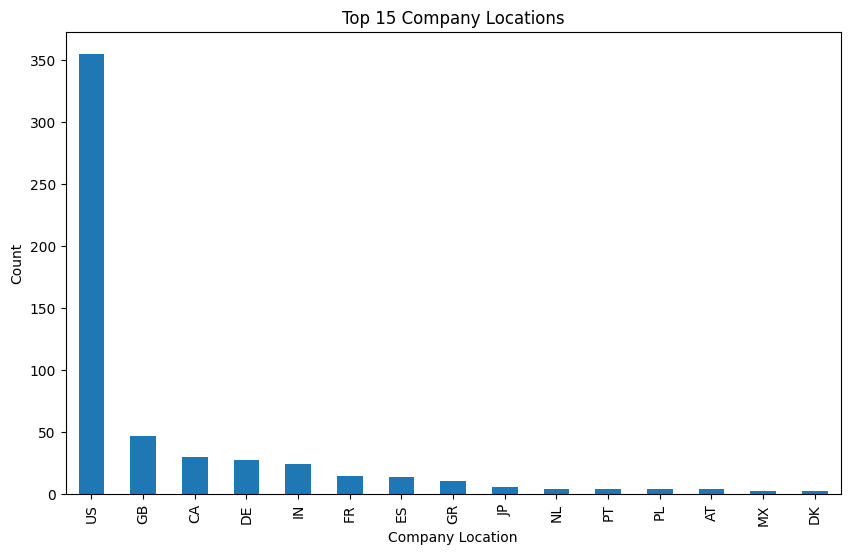

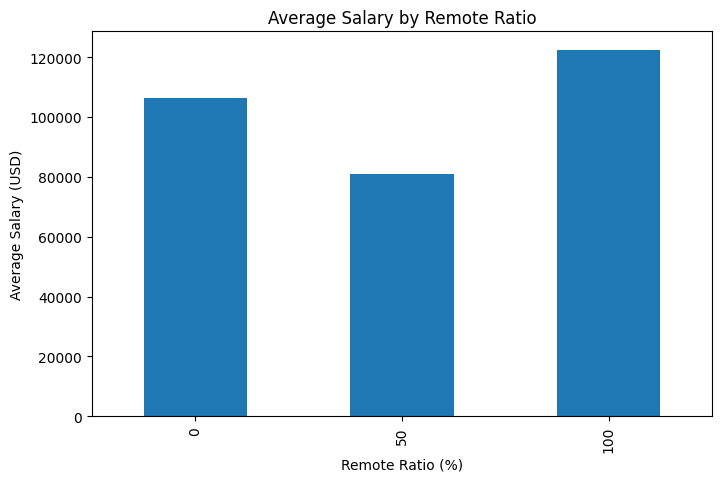

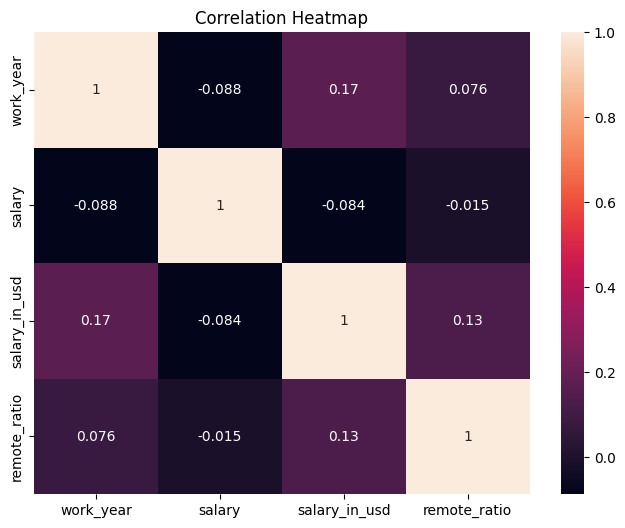

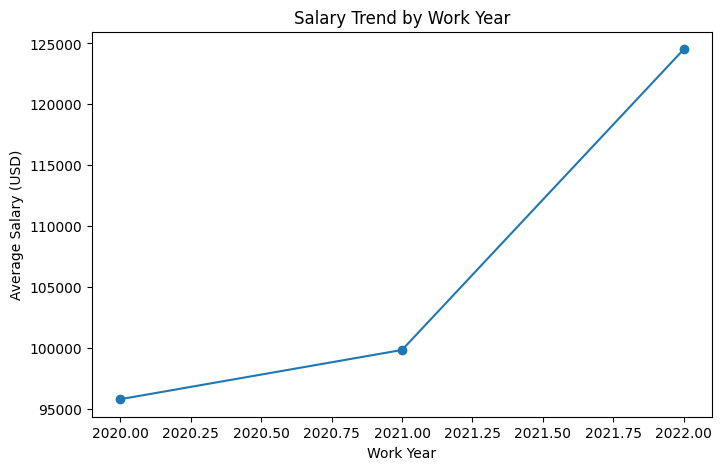

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_all(df):
    plt.figure(figsize=(8,5))
    sns.distplot(df["salary_in_usd"], kde=True)
    plt.xlabel("Salary (USD)")
    plt.ylabel("Count")
    plt.title("Salary Distribution")
    plt.show()

    top_titles = df["job_title"].value_counts().head(10).index
    freq = df["job_title"].value_counts().loc[top_titles]
    plt.figure(figsize=(10,6))
    freq.plot(kind="bar")
    plt.xlabel("Job Title")
    plt.ylabel("Count")
    plt.title("Top 10 Job Titles Frequency")
    plt.xticks(rotation=90)
    plt.show()

    exp_avg = df.groupby("experience_level")["salary_in_usd"].mean()
    plt.figure(figsize=(8,5))
    exp_avg.plot(kind="bar")
    plt.xlabel("Experience Level")
    plt.ylabel("Average Salary (USD)")
    plt.title("Average Salary by Experience Level")
    plt.show()

    comp_avg = df.groupby("company_size")["salary_in_usd"].mean()
    plt.figure(figsize=(8,5))
    comp_avg.plot(kind="bar")
    plt.xlabel("Company Size")
    plt.ylabel("Average Salary (USD)")
    plt.title("Average Salary by Company Size")
    plt.show()

    top_loc = df["company_location"].value_counts().head(15)
    plt.figure(figsize=(10,6))
    top_loc.plot(kind="bar")
    plt.xlabel("Company Location")
    plt.ylabel("Count")
    plt.title("Top 15 Company Locations")
    plt.show()

    remote_avg = df.groupby("remote_ratio")["salary_in_usd"].mean()
    plt.figure(figsize=(8,5))
    remote_avg.plot(kind="bar")
    plt.xlabel("Remote Ratio (%)")
    plt.ylabel("Average Salary (USD)")
    plt.title("Average Salary by Remote Ratio")
    plt.show()

    numeric = df.select_dtypes(include=["int64","float64"])
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric.corr(), annot=True)
    plt.title("Correlation Heatmap")
    plt.show()

    year_salary = df.groupby("work_year")["salary_in_usd"].mean()
    plt.figure(figsize=(8,5))
    year_salary.plot(kind="line", marker="o")
    plt.xlabel("Work Year")
    plt.ylabel("Average Salary (USD)")
    plt.title("Salary Trend by Work Year")
    plt.show()

visualize_all(df)


In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

algorithm_names = []
MAE_list = []
MSE_list = []
RMSE_list = []
R2_list = []

def calculateRegressionMetrics(algorithm, predict, testY):

    mae = mean_absolute_error(testY, predict)
    mse = mean_squared_error(testY, predict)
    rmse = np.sqrt(mse)
    r2 = r2_score(testY, predict)


    print(f"{algorithm} Mean Absolute Error (MAE): {mae:.2f}")
    print(f"{algorithm} Mean Squared Error (MSE): {mse:.2f}")
    print(f"{algorithm} Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"{algorithm} R2 Score: {r2:.2f}")


    algorithm_names.append(algorithm)
    MAE_list.append(mae)
    MSE_list.append(mse)
    RMSE_list.append(rmse)
    R2_list.append(r2)

    plt.figure(figsize=(7, 7))
    plt.scatter(testY, predict, color='blue', alpha=0.6)
    plt.plot([min(testY), max(testY)], [min(testY), max(testY)], color='red', linestyle='--', linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{algorithm} Predicted vs Actual Values")
    plt.grid(True)
    plt.show()


## splitting X,Y for model building

In [87]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Building and training

Linear Regression Mean Absolute Error (MAE): 35686.20
Linear Regression Mean Squared Error (MSE): 2592393109.09
Linear Regression Root Mean Squared Error (RMSE): 50915.55
Linear Regression R2 Score: 0.32


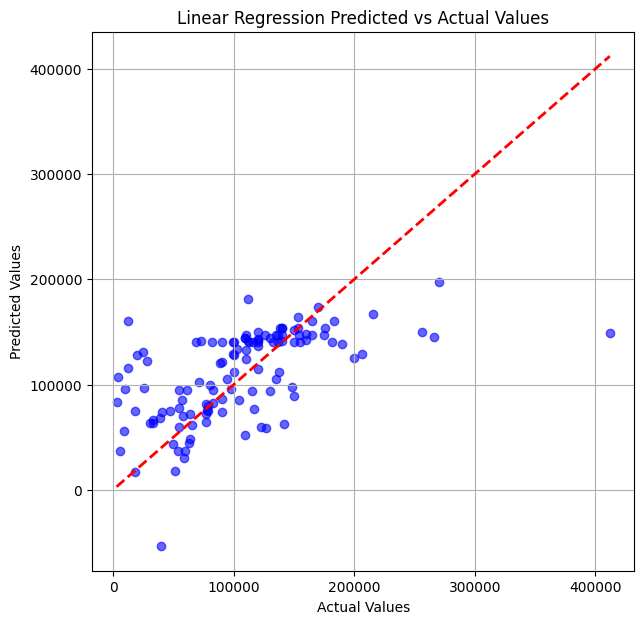

In [88]:
from sklearn.linear_model import LinearRegression
import joblib
model_path = f"{folder}/linear_regressor.pkl"

if os.path.exists(model_path):
    lr_model = joblib.load(model_path)
    preds = lr_model.predict(x_test)
    calculateRegressionMetrics("Linear Regression", preds, y_test)
else:
    lr_model = LinearRegression()
    lr_model.fit(x_train, y_train)
    preds = lr_model.predict(x_test)
    joblib.dump(lr_model, model_path)
    print("Linear Regression trained and saved.")
    calculateRegressionMetrics("Linear Regression", preds, y_test)


KNN Regressor Mean Absolute Error (MAE): 25581.17
KNN Regressor Mean Squared Error (MSE): 2026299767.78
KNN Regressor Root Mean Squared Error (RMSE): 45014.44
KNN Regressor R2 Score: 0.47


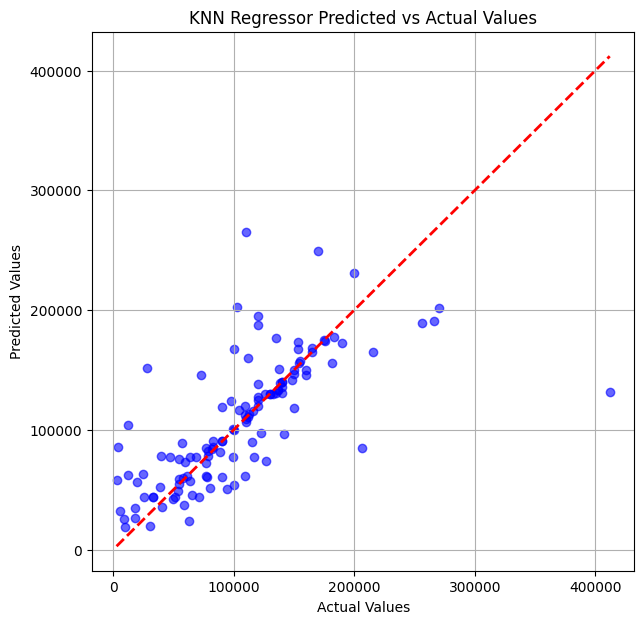

In [89]:
from sklearn.neighbors import KNeighborsRegressor

model_path = f"{folder}/knn_regressor.pkl"

if os.path.exists(model_path):
    knn = joblib.load(model_path)
    preds = knn.predict(x_test)
    calculateRegressionMetrics("KNN Regressor", preds, y_test)
else:
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
    knn.fit(x_train, y_train)
    preds = knn.predict(x_test)
    joblib.dump(knn, model_path)
    print("KNN Regressor trained and saved.")
    calculateRegressionMetrics("KNN Regressor", preds, y_test)


Huber Regressor Mean Absolute Error (MAE): 35078.38
Huber Regressor Mean Squared Error (MSE): 2546751066.66
Huber Regressor Root Mean Squared Error (RMSE): 50465.35
Huber Regressor R2 Score: 0.34


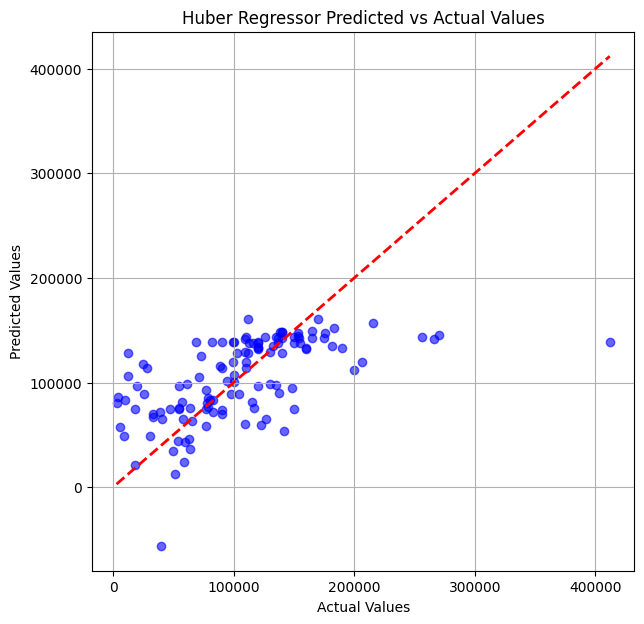

In [90]:
from sklearn.linear_model import HuberRegressor

model_path = f"{folder}/huber_regressor.pkl"

if os.path.exists(model_path):
    huber = joblib.load(model_path)
    preds = huber.predict(x_test)
    calculateRegressionMetrics("Huber Regressor", preds, y_test)
else:
    huber = HuberRegressor(max_iter=1000)
    huber.fit(x_train, y_train)
    preds = huber.predict(x_test)
    joblib.dump(huber, model_path)
    print("Huber Regressor trained and saved.")
    calculateRegressionMetrics("Huber Regressor", preds, y_test)


HistGradientBoosting Mean Absolute Error (MAE): 5681.90
HistGradientBoosting Mean Squared Error (MSE): 125126735.50
HistGradientBoosting Root Mean Squared Error (RMSE): 11186.01
HistGradientBoosting R2 Score: 0.97


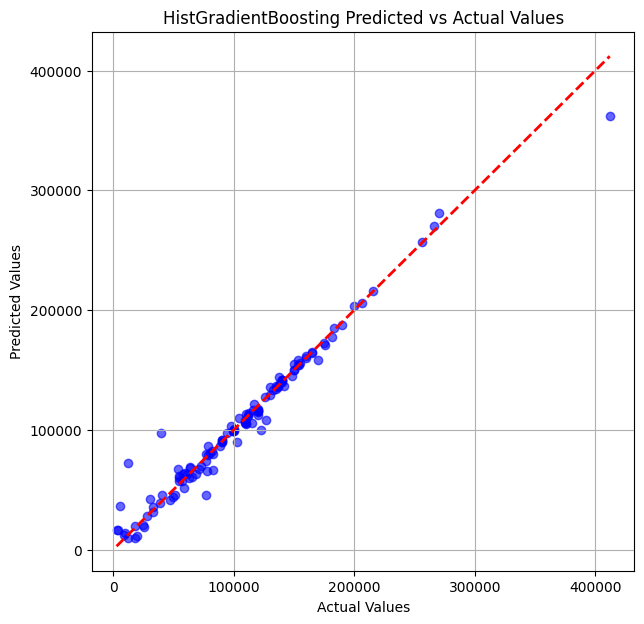

In [91]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_path = f"{folder}/histgradient_regressor.pkl"

if os.path.exists(model_path):
    hgb = joblib.load(model_path)
    preds = hgb.predict(x_test)
    calculateRegressionMetrics("HistGradientBoosting", preds, y_test)
else:
    hgb = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        l2_regularization=0.1,
        random_state=42
    )
    hgb.fit(x_train, y_train)
    preds = hgb.predict(x_test)
    joblib.dump(hgb, model_path)
    print("HistGradientBoosting Regressor trained and saved.")
    calculateRegressionMetrics("HistGradientBoosting", preds, y_test)

C:\Users\bhuky\AppData\Local\Temp\ipykernel_1660\2376902416.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


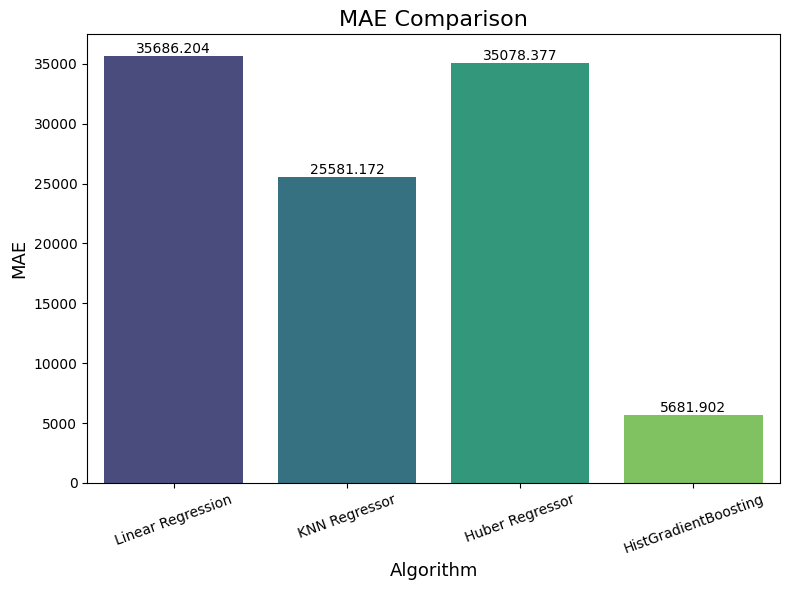

C:\Users\bhuky\AppData\Local\Temp\ipykernel_1660\2376902416.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


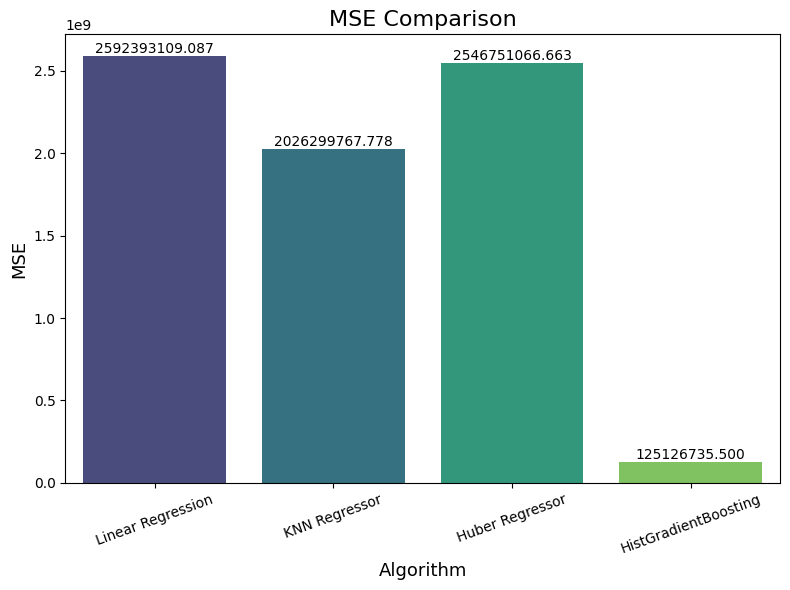

C:\Users\bhuky\AppData\Local\Temp\ipykernel_1660\2376902416.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


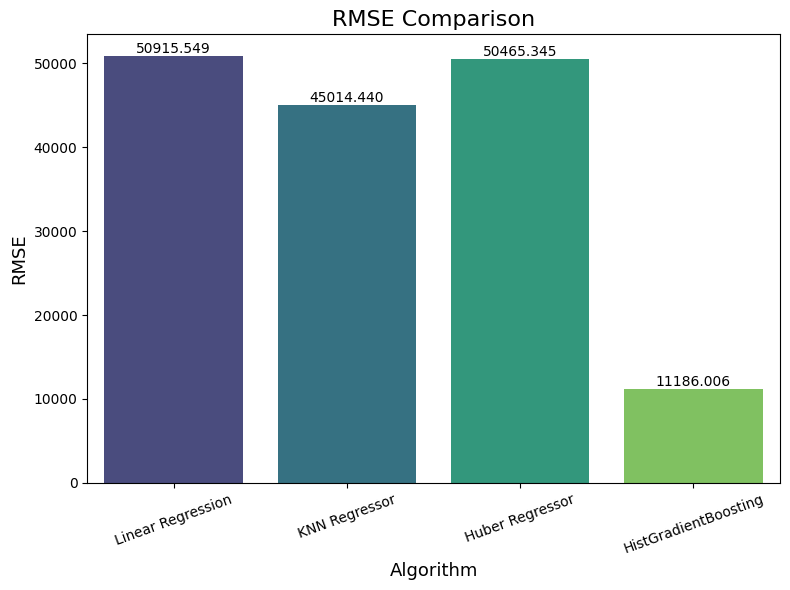

C:\Users\bhuky\AppData\Local\Temp\ipykernel_1660\2376902416.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


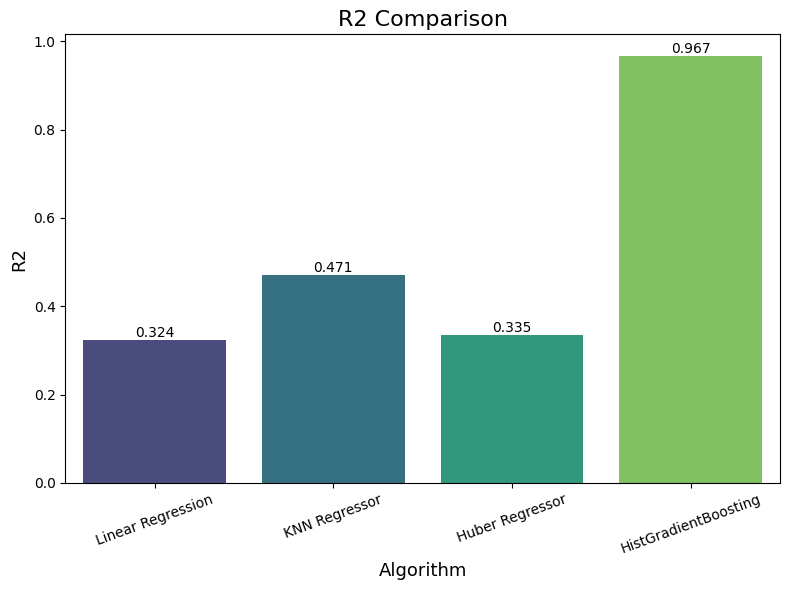

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_metrics(algorithm_names, MAE_list, MSE_list, RMSE_list, R2_list):
    data = {
        "algorithm_name": algorithm_names,
        "MAE": MAE_list,
        "MSE": MSE_list,
        "RMSE": RMSE_list,
        "R2": R2_list
    }

    df = pd.DataFrame(data)
    metrics = ["MAE", "MSE", "RMSE", "R2"]

    for metric in metrics:
        plt.figure(figsize=(8, 6))
        ax = sns.barplot(
            x="algorithm_name",
            y=metric,
            data=df,
            palette="viridis"
        )

        for p in ax.patches:
            v = p.get_height()
            ax.annotate(
                f"{v:.3f}",
                (p.get_x() + p.get_width() / 2, v),
                ha='center', va='bottom',
                fontsize=10, color='black'
            )

        plt.title(f"{metric} Comparison", fontsize=16)
        plt.xlabel("Algorithm", fontsize=13)
        plt.ylabel(metric, fontsize=13)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
plot_all_metrics(algorithm_names, MAE_list, MSE_list, RMSE_list, R2_list)


# Predictions

In [93]:
testdata = pd.read_csv('Dataset/Testdata.csv')
testdata

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
0,0.859977,2,2,44,-0.161365,16,8,0.714862,6,2
1,-0.586023,0,2,12,-0.158125,16,55,0.714862,48,1
2,-2.032024,2,2,17,-0.167846,7,2,-0.514377,2,0
3,0.859977,2,2,12,-0.197008,16,21,0.714862,19,2
4,0.859977,2,2,38,-0.132203,16,55,0.714862,48,2
5,-0.586023,0,3,12,-0.204292,7,18,-0.514377,16,1
6,0.859977,3,2,12,-0.145164,16,55,0.714862,48,1
7,0.859977,3,2,16,-0.037328,16,55,0.714862,48,1
8,-0.586023,2,2,17,-0.207377,16,29,0.714862,27,1
9,-0.586023,0,2,38,-0.197008,16,27,0.714862,25,2


In [94]:
pred = hgb.predict(testdata)
pred

array([ 72658.77087258,  81032.28914006,  61476.2321262 ,  17361.67784408,
       115737.5706555 ,  15686.71801275, 101124.35009018, 270655.34766225,
        12470.00536019,  15667.886695  ,  13559.40009097,  31828.86133946,
        92956.73725604,  94396.19959426,  74424.08564942, 127151.11558136,
       112863.70995259, 265806.24854095, 148775.72491659,  41412.11881928])

In [95]:
testdata['Predicted as'] = pred.round().astype(int)
testdata

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,Predicted as
0,0.859977,2,2,44,-0.161365,16,8,0.714862,6,2,72659
1,-0.586023,0,2,12,-0.158125,16,55,0.714862,48,1,81032
2,-2.032024,2,2,17,-0.167846,7,2,-0.514377,2,0,61476
3,0.859977,2,2,12,-0.197008,16,21,0.714862,19,2,17362
4,0.859977,2,2,38,-0.132203,16,55,0.714862,48,2,115738
5,-0.586023,0,3,12,-0.204292,7,18,-0.514377,16,1,15687
6,0.859977,3,2,12,-0.145164,16,55,0.714862,48,1,101124
7,0.859977,3,2,16,-0.037328,16,55,0.714862,48,1,270655
8,-0.586023,2,2,17,-0.207377,16,29,0.714862,27,1,12470
9,-0.586023,0,2,38,-0.197008,16,27,0.714862,25,2,15668
